In [4]:
import pandas as pd
import numpy as np

# Please place the file "electricity-demand-dataset.csv" in your Google Drive folder named "Data" to run this cell.
# This allows you to access the dataset directly without re-uploading it each time you open the notebook in Google Colab.
# If you prefer not to host the file in Drive, modify the file path to read from the current working directory in Colab instead.

# from google.colab import drive
# drive.mount("/content/drive")

CSV_PATH = "electricity-demand-dataset.csv"
df = pd.read_csv(CSV_PATH).copy()

# --- Timestamp (date-only) ---
df["Timestamp_dt"] = pd.to_datetime(
    df["Timestamp"].astype(str).str.strip(),
    format="%d-%b-%y",
    errors="coerce"
)

# --- Fix hour (neighbor stepping) ---
h = pd.to_numeric(df["hour"], errors="coerce")

for i in range(1, len(h)):
    if pd.isna(h.iat[i]) and pd.notna(h.iat[i-1]):
        h.iat[i] = (int(h.iat[i-1]) + 1) % 24

for i in range(len(h) - 2, -1, -1):
    if pd.isna(h.iat[i]) and pd.notna(h.iat[i+1]):
        h.iat[i] = (int(h.iat[i+1]) - 1) % 24

# drop any rows where hour still missing
df = df.loc[~h.isna()].copy()
df["hour"] = h.loc[df.index].astype(int)

# --- Build ds ---
df["ds"] = df["Timestamp_dt"] + pd.to_timedelta(df["hour"], unit="h")

# --- Ensure numeric + interpolate continuous columns over time ---
df = df.sort_values("ds").reset_index(drop=True)
for col in ["Temperature", "Humidity", "Demand"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.set_index("ds")
df[["Temperature", "Humidity", "Demand"]] = df[["Temperature", "Humidity", "Demand"]].interpolate(
    method="time", limit_direction="both"
)
df = df.reset_index()

# quick sanity check
print(df[["ds","Demand","Temperature","Humidity"]].isna().sum())
print(df["ds"].min(), "->", df["ds"].max(), "| rows:", len(df))

ds             0
Demand         0
Temperature    0
Humidity       0
dtype: int64
2020-01-01 00:00:00 -> 2024-12-31 23:00:00 | rows: 43848


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = df.sort_values("ds").reset_index(drop=True)

def add_cyclical_time_features(dfin):
    d = dfin.copy()
    hour = d["ds"].dt.hour.to_numpy()
    dow  = d["ds"].dt.weekday.to_numpy()
    doy  = d["ds"].dt.dayofyear.to_numpy()

    d["hour_sin"] = np.sin(2*np.pi*hour/24.0)
    d["hour_cos"] = np.cos(2*np.pi*hour/24.0)
    d["dow_sin"]  = np.sin(2*np.pi*dow/7.0)
    d["dow_cos"]  = np.cos(2*np.pi*dow/7.0)
    d["doy_sin"]  = np.sin(2*np.pi*doy/365.0)
    d["doy_cos"]  = np.cos(2*np.pi*doy/365.0)
    return d

def train_eval_ffnn(df_feat, feature_cols, title, epochs=100, batch_size=1024, lr=1e-3):
    train = df_feat[df_feat["ds"].dt.year <= 2023].copy()
    test  = df_feat[df_feat["ds"].dt.year == 2024].copy()

    # drop rows with NaNs in needed columns
    train = train.dropna(subset=feature_cols + ["Demand"])
    test  = test.dropna(subset=feature_cols + ["Demand"])

    Xtr = train[feature_cols].to_numpy(dtype=np.float32)
    ytr = train["Demand"].to_numpy(dtype=np.float32).reshape(-1, 1)

    Xte = test[feature_cols].to_numpy(dtype=np.float32)
    yte = test["Demand"].to_numpy(dtype=np.float32).reshape(-1, 1)

    x_scaler = RobustScaler().fit(Xtr)
    y_scaler = RobustScaler().fit(ytr)

    Xtr_s = x_scaler.transform(Xtr).astype(np.float32)
    Xte_s = x_scaler.transform(Xte).astype(np.float32)
    ytr_s = y_scaler.transform(ytr).astype(np.float32)

    tr_loader = DataLoader(
        TensorDataset(torch.from_numpy(Xtr_s), torch.from_numpy(ytr_s)),
        batch_size=batch_size, shuffle=True
    )

    model = nn.Sequential(
        nn.Linear(Xtr_s.shape[1], 6), nn.ReLU(),
        nn.Linear(6, 3), nn.ReLU(),
        nn.Linear(3, 1)
    )

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    model.train()
    for ep in range(epochs):
        tot = 0.0
        for xb, yb in tr_loader:
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * xb.size(0)
        if (ep+1) % 2 == 0 or ep == 0:
            print(f"{title} | epoch {ep+1}/{epochs} | train MSE (scaled) = {tot/len(train):.4f}")

    model.eval()
    with torch.no_grad():
        yhat_s = model(torch.from_numpy(Xte_s)).numpy()
    yhat = y_scaler.inverse_transform(yhat_s).reshape(-1)

    y_true = yte.reshape(-1)

    print(f"\n{title} | 2024 metrics:")
    print("MAE :", mean_absolute_error(y_true, yhat))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, yhat)))
    print("R^2 :", r2_score(y_true, yhat))

    plt.figure()
    plt.plot(test["ds"], y_true, label="Actual")
    plt.plot(test["ds"], yhat, label="Predicted")
    plt.title(f"2024 Actual vs Predicted Demand ({title})")
    plt.xlabel("Time")
    plt.ylabel("Demand")
    plt.legend()
    plt.tight_layout()
    plt.show()

FFNN-1 (calendar-only) | epoch 1/100 | train MSE (scaled) = 0.5106
FFNN-1 (calendar-only) | epoch 2/100 | train MSE (scaled) = 0.4552
FFNN-1 (calendar-only) | epoch 4/100 | train MSE (scaled) = 0.3125
FFNN-1 (calendar-only) | epoch 6/100 | train MSE (scaled) = 0.1926
FFNN-1 (calendar-only) | epoch 8/100 | train MSE (scaled) = 0.1433
FFNN-1 (calendar-only) | epoch 10/100 | train MSE (scaled) = 0.1201
FFNN-1 (calendar-only) | epoch 12/100 | train MSE (scaled) = 0.1028
FFNN-1 (calendar-only) | epoch 14/100 | train MSE (scaled) = 0.0881
FFNN-1 (calendar-only) | epoch 16/100 | train MSE (scaled) = 0.0755
FFNN-1 (calendar-only) | epoch 18/100 | train MSE (scaled) = 0.0648
FFNN-1 (calendar-only) | epoch 20/100 | train MSE (scaled) = 0.0558
FFNN-1 (calendar-only) | epoch 22/100 | train MSE (scaled) = 0.0487
FFNN-1 (calendar-only) | epoch 24/100 | train MSE (scaled) = 0.0434
FFNN-1 (calendar-only) | epoch 26/100 | train MSE (scaled) = 0.0396
FFNN-1 (calendar-only) | epoch 28/100 | train MSE (sc

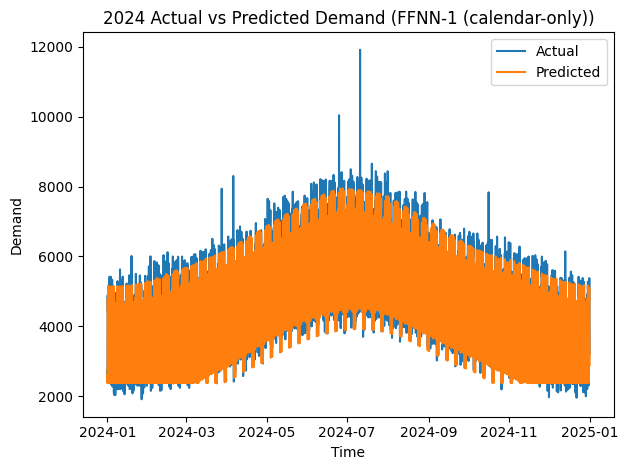

In [6]:
df1 = add_cyclical_time_features(df)

feat1 = ["hour_sin","hour_cos","dow_sin","dow_cos","doy_sin","doy_cos"]
train_eval_ffnn(df1, feat1, title="FFNN-1 (calendar-only)")

FFNN-2 (calendar + temp/humidity) | epoch 1/100 | train MSE (scaled) = 0.6394
FFNN-2 (calendar + temp/humidity) | epoch 2/100 | train MSE (scaled) = 0.5500
FFNN-2 (calendar + temp/humidity) | epoch 4/100 | train MSE (scaled) = 0.3546
FFNN-2 (calendar + temp/humidity) | epoch 6/100 | train MSE (scaled) = 0.1936
FFNN-2 (calendar + temp/humidity) | epoch 8/100 | train MSE (scaled) = 0.1376
FFNN-2 (calendar + temp/humidity) | epoch 10/100 | train MSE (scaled) = 0.1138
FFNN-2 (calendar + temp/humidity) | epoch 12/100 | train MSE (scaled) = 0.0984
FFNN-2 (calendar + temp/humidity) | epoch 14/100 | train MSE (scaled) = 0.0850
FFNN-2 (calendar + temp/humidity) | epoch 16/100 | train MSE (scaled) = 0.0720
FFNN-2 (calendar + temp/humidity) | epoch 18/100 | train MSE (scaled) = 0.0613
FFNN-2 (calendar + temp/humidity) | epoch 20/100 | train MSE (scaled) = 0.0529
FFNN-2 (calendar + temp/humidity) | epoch 22/100 | train MSE (scaled) = 0.0465
FFNN-2 (calendar + temp/humidity) | epoch 24/100 | train 

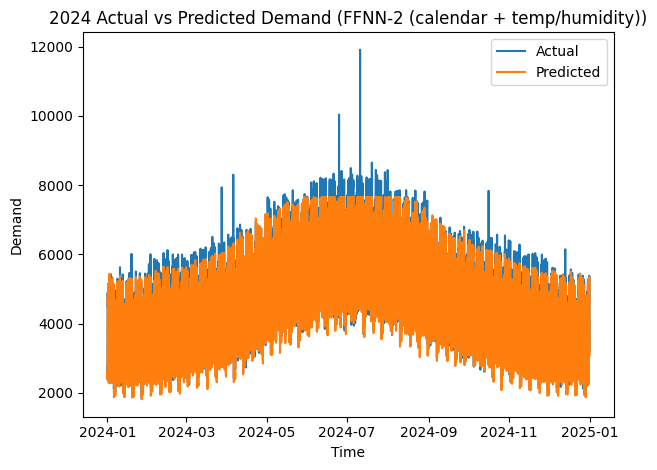

In [7]:
df2 = add_cyclical_time_features(df)

feat2 = ["hour_sin","hour_cos","dow_sin","dow_cos","doy_sin","doy_cos",
         "Temperature","Humidity"]
train_eval_ffnn(df2, feat2, title="FFNN-2 (calendar + temp/humidity)")

FFNN-3 (calendar + temp/humidity + lags1..6) | epoch 1/100 | train MSE (scaled) = 0.8672
FFNN-3 (calendar + temp/humidity + lags1..6) | epoch 2/100 | train MSE (scaled) = 0.7570
FFNN-3 (calendar + temp/humidity + lags1..6) | epoch 4/100 | train MSE (scaled) = 0.5909
FFNN-3 (calendar + temp/humidity + lags1..6) | epoch 6/100 | train MSE (scaled) = 0.4402
FFNN-3 (calendar + temp/humidity + lags1..6) | epoch 8/100 | train MSE (scaled) = 0.1948
FFNN-3 (calendar + temp/humidity + lags1..6) | epoch 10/100 | train MSE (scaled) = 0.0642
FFNN-3 (calendar + temp/humidity + lags1..6) | epoch 12/100 | train MSE (scaled) = 0.0414
FFNN-3 (calendar + temp/humidity + lags1..6) | epoch 14/100 | train MSE (scaled) = 0.0333
FFNN-3 (calendar + temp/humidity + lags1..6) | epoch 16/100 | train MSE (scaled) = 0.0289
FFNN-3 (calendar + temp/humidity + lags1..6) | epoch 18/100 | train MSE (scaled) = 0.0262
FFNN-3 (calendar + temp/humidity + lags1..6) | epoch 20/100 | train MSE (scaled) = 0.0242
FFNN-3 (calenda

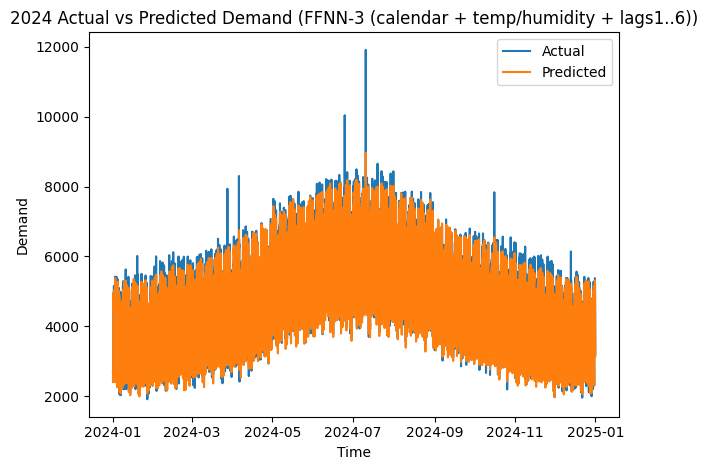

In [8]:
df3 = add_cyclical_time_features(df).copy()

for k in range(1, 7):
    df3[f"lag{k}"] = df3["Demand"].shift(k)

lag_cols = [f"lag{k}" for k in range(1, 7)]

feat3 = ["hour_sin","hour_cos","dow_sin","dow_cos","doy_sin","doy_cos",
         "Temperature","Humidity"] + lag_cols

train_eval_ffnn(df3, feat3, title="FFNN-3 (calendar + temp/humidity + lags1..6)")